# Foundation models with series of different lengths and exogenous variables

Real multi-series datasets are rarely tidy. Some series start recording later than others, some stop before the end of the observation period, a sensor fails and leaves a block of missing values, and not every series has the same set of covariates available. For global machine learning models, skforecast handles this heterogeneity in [ForecasterRecursiveMultiSeries](../user_guides/multi-series-with-different-length-and-different_exog.ipynb) by building one training matrix from whatever each series has.

Foundation models pose a different challenge. They do not train on the data: at predict time, the series are sent in a batch to a pre-trained backend (Chronos-2, TimesFM, TabPFN-TS, and so on), and each backend has its own rules about what a batch may contain. [`ForecasterFoundation`](../api/ForecasterFoundation.md) and [`FoundationModel`](../api/FoundationModel.md) absorb those rules, so the same code works whatever the shape of the data. This guide shows it with a worked example, explains what happens under the hood, and ends with a reference of what each backend requires and tolerates.


<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161; Tip</b>
</p>

This guide assumes familiarity with the basics of <a href="../user_guides/foundation-forecasting-models.html">forecasting with foundation models</a> in skforecast: the role of the context window, the <code>fit</code> / <code>predict</code> semantics and the supported backends.

</div>

## In short

| Question | Answer |
|:---------|:-------|
| Can the series have different lengths and spans? | Yes. Each series is forecast from its own context window and its own horizon, which starts right after its last observation. |
| Can each series have a different subset of exog columns? | Yes. Each series is validated and forecast with its own columns. Backends that need identical columns per batch are called once per group of series sharing the same columns. |
| Can a series lack exog while others have it? | Yes. It is forecast without covariates. |
| Can a future exog column be absent from the history? | No. It raises a `ValueError` for that series. |
| Can the target contain NaN? | Yes for every current backend, each one handles NaN in its own way (see the reference at the end). A context window that is entirely NaN is rejected. |
| Does batching series together change their forecasts? | Not for Chronos-2, TS-ICL and TabICL: the forecast of a series is identical to forecasting it alone. TimesFM 3.0 with covariates can shift the forecast of a short series slightly when batched with longer ones. |
| How do I know what a backend needs? | Inspect `allow_exog`, `supports_past_only_covariates`, `supports_heterogeneous_covariates` and `supports_nan_in_series` on the forecaster (see [How it works](#how-it-works)). |

## Libraries and data

The example uses the same dataset as the [global models guide](../user_guides/multi-series-with-different-length-and-different_exog.ipynb) on series of different lengths: five daily series in long format, together with four exogenous variables. Two series are deliberately stripped of some exogenous columns so that every axis of heterogeneity (lengths, time spans, exog subsets and missing values) is present at once.

In [9]:
# Libraries
# ==============================================================================
import pandas as pd
from skforecast.plot import set_dark_theme
import matplotlib.pyplot as plt
from skforecast.foundation import FoundationModel, ForecasterFoundation
from skforecast.preprocessing import reshape_series_long_to_dict, reshape_exog_long_to_dict
from skforecast.model_selection import TimeSeriesFold, backtesting_foundation

In [10]:
# Load time series of multiple lengths and exogenous variables
# ==============================================================================
series = pd.read_csv(
    'https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/demo_multi_series.csv'
)
exog = pd.read_csv(
    'https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/demo_multi_series_exog.csv'
)

series['timestamp'] = pd.to_datetime(series['timestamp'])
exog['timestamp'] = pd.to_datetime(exog['timestamp'])

display(series.head(3))
print("")
display(exog.head(3))


,series_id,timestamp,value
0,id_1000,2016-01-01,1012.500694
1,id_1000,2016-01-02,1158.500099
2,id_1000,2016-01-03,983.000099


,series_id,timestamp,sin_day_of_week,cos_day_of_week,air_temperature,wind_speed
0,id_1000,2016-01-01,-0.433884,-0.900969,6.416639,4.040115
1,id_1000,2016-01-02,-0.974928,-0.222521,6.366474,4.530395
2,id_1000,2016-01-03,-0.781831,0.623490,6.555272,3.273064


The series and the exogenous variables are converted to dictionaries with <code>[reshape_series_long_to_dict](../api/preprocessing.html#skforecast.preprocessing.preprocessing.reshape_series_long_to_dict)</code> and <code>[reshape_exog_long_to_dict](../api/preprocessing.html#skforecast.preprocessing.preprocessing.reshape_exog_long_to_dict)</code>. A dictionary is the most efficient input format for series of different lengths, although a wide or long-format DataFrame is accepted as well. Setting the daily frequency introduces NaN in `id_1003` where the raw data has no rows, which `reshape_series_long_to_dict` reports with a warning.

In [11]:

# Transform series and exog to dictionaries
# ==============================================================================
series_dict = reshape_series_long_to_dict(
    data      = series,
    series_id = 'series_id',
    index     = 'timestamp',
    values    = 'value',
    freq      = 'D'
)
exog_dict = reshape_exog_long_to_dict(
    data      = exog,
    series_id = 'series_id',
    index     = 'timestamp',
    freq      = 'D'
)

# Drop some exogenous variables for series 'id_1000' and 'id_1003'
# ==============================================================================
exog_dict['id_1000'] = exog_dict['id_1000'].drop(columns=['air_temperature', 'wind_speed'])
exog_dict['id_1003'] = exog_dict['id_1003'].drop(columns=['cos_day_of_week'])

# Partition data in train and test
# ==============================================================================
end_train = '2016-07-31 23:59:00'
series_dict_train = {k: v.loc[:end_train] for k, v in series_dict.items()}
exog_dict_train   = {k: v.loc[:end_train] for k, v in exog_dict.items()}
exog_dict_test    = {k: v.loc[end_train:] for k, v in exog_dict.items()}

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ Series 'id_1003' is incomplete. NaNs have been introduced after setting the          │
│ frequency.                                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/preprocessing/_preprocessing.py:531                                   │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

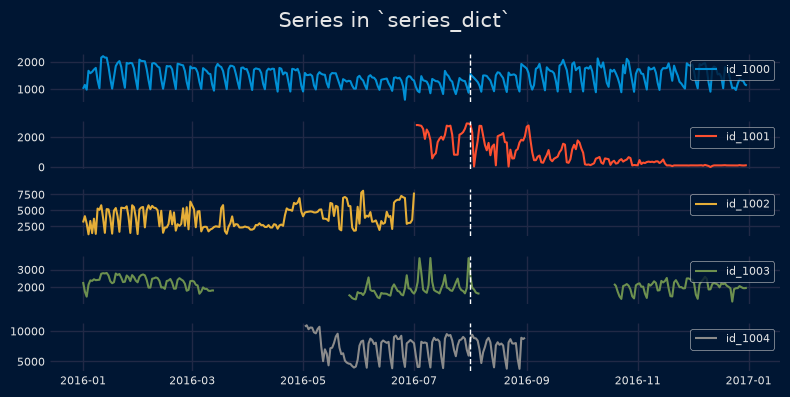

In [12]:
# Plot series
# ==============================================================================
set_dark_theme()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axs = plt.subplots(5, 1, figsize=(8, 4), sharex=True)

for i, s in enumerate(series_dict.values()):
    axs[i].plot(s, label=s.name, color=colors[i])
    axs[i].legend(loc='upper right', fontsize=8)
    axs[i].tick_params(axis='both', labelsize=8)
    axs[i].axvline(
        pd.to_datetime(end_train), color='white', linestyle='--', linewidth=1
    )  # End train

fig.suptitle('Series in `series_dict`', fontsize=15)
plt.tight_layout()

The resulting dataset looks like this:

| Series | Span | Train length | NaN in target | Exogenous columns |
|:-------|:-----|-------------:|:--------------|:------------------|
| `id_1000` | 2016-01-01 to 2016-12-31 | 213 | No | `sin_day_of_week`, `cos_day_of_week` |
| `id_1001` | 2016-07-02 to 2016-12-31 | 30 | No | `sin_day_of_week`, `cos_day_of_week`, `air_temperature`, `wind_speed` |
| `id_1002` | 2016-01-01 to 2016-07-01 | 183 | No | `sin_day_of_week`, `cos_day_of_week`, `air_temperature`, `wind_speed` |
| `id_1003` | 2016-01-01 to 2016-12-31 | 213 | Yes, several blocks | `sin_day_of_week`, `air_temperature`, `wind_speed` |
| `id_1004` | 2016-05-02 to 2016-08-31 | 91 | No | `sin_day_of_week`, `cos_day_of_week`, `air_temperature`, `wind_speed` |

Mixed lengths (30 to 213 training observations), a series that starts late (`id_1001`), a series that ends before the split (`id_1002`, no test data at all), a series that ends one month into the test period (`id_1004`), three different exog subsets, and NaN blocks in `id_1003`.

## Fit and predict

Nothing in the code below is specific to heterogeneous data. `fit` stores the last `context_length` observations of each series together with its exog, and `predict` sends them to the backend.

In [13]:
# Fit with ForecasterFoundation
# ==============================================================================
# Available model_ids
# "autogluon/chronos-2-small",
# "google/timesfm-3.0-pytorch",
# "google/timesfm-2.5-200m-pytorch",
# "soda-inria/tabicl",
# "priorlabs/tabpfn-ts",
# "theforecastingcompany/t0-alpha",
# "Synthefy/Nori",
# "taharnbl/TS-ICL"

forecaster = ForecasterFoundation(
    estimator=FoundationModel(
        model_id       = "autogluon/chronos-2-small",
        context_length = 500,
    )
)

forecaster.fit(series=series_dict_train, exog=exog_dict_train)
forecaster

==================== 
ForecasterFoundation 
==================== 
Model ID: autogluon/chronos-2-small 
Context length: 500 
Series names: id_1000, id_1001, id_1002, id_1003, id_1004 
Exogenous included: True 
Exogenous names: 
    sin_day_of_week, air_temperature, wind_speed, cos_day_of_week 
Context range: {'id_1000': [Timestamp('2016-01-01 00:00:00'), Timestamp('2016-07-31 00:00:00')], 'id_1001': [Timestamp('2016-07-02 00:00:00'), Timestamp('2016-07-31 00:00:00')], 'id_1002': [Timestamp('2016-01-01 00:00:00'), Timestamp('2016-07-01 00:00:00')], 'id_1003': [Timestamp('2016-01-01 00:00:00'), Timestamp('2016-07-31 00:00:00')], 'id_1004': [Timestamp('2016-05-02 00:00:00'), Timestamp('2016-07-31 00:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Creation date: 2026-09-11 14:25:27 
Last fit date: 2026-09-11 14:25:27 
Skforecast version: 0.25.0 
Python version: 3.14.3 
Forecaster id: None

In [14]:
# Predict with ForecasterFoundation
# ==============================================================================
predictions = forecaster.predict(steps=5, exog=exog_dict_test)
predictions.head(10)

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ `exog` for series ['id_1002'] has been reindexed to match the expected forecast      │
│ horizon. Missing timestamps were filled with NaN.                                    │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_51523/961589088.py:3      │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

,level,pred
2016-08-01,id_1000,1231.922119
2016-08-01,id_1001,2801.006836
2016-07-02,id_1002,5641.508789
2016-08-01,id_1003,3102.707275
2016-08-01,id_1004,8169.243164
2016-08-02,id_1000,1356.914307
2016-08-02,id_1001,2594.931152
2016-07-03,id_1002,3941.421143
2016-08-02,id_1003,2107.814453
2016-08-02,id_1004,8841.991211


What happens inside that `predict` call:

- The horizon of every series starts right after its own last training observation: `id_1000`, `id_1001`, `id_1003` and `id_1004` are forecast from 2016-08-01, `id_1002` from 2016-07-02.
- `exog_dict_test['id_1002']` is empty because that series (and its exog) ended before the split. Its future exog is reindexed to the horizon and filled with NaN, and a `MissingValuesWarning` names the series. Chronos-2 treats those NaN as missing covariate values.
- Every series is validated against its own history, so `id_1000` is forecast with two covariates, `id_1003` with three and the other series with four. Chronos-2 requires identical covariate columns in a batch, so the five series are forecast in three backend calls: one for `id_1000`, one for `id_1003`, and one for `id_1001`, `id_1002` and `id_1004`. With TabPFN-TS or TFC-T0 the same input would be a single call.
- The NaN blocks in `id_1003` stay in its context window. With a backend declaring `supports_nan_in_series=False`, `predict` would raise a `ValueError` naming the series.

The same code runs unchanged with any other covariate-aware `model_id` (`google/timesfm-3.0-pytorch`, `soda-inria/tabicl`, `priorlabs/tabpfn-ts`, `theforecastingcompany/t0-alpha`, `Synthefy/Nori`, `taharnbl/TS-ICL`); with `google/timesfm-2.5-200m-pytorch` or `Salesforce/moirai-2.0-R-small` the exog is ignored with an `IgnoredArgumentWarning`.

## Backtesting

`backtesting_foundation` applies the same alignment and grouping in every fold, and adds its own rules so that every prediction is dated inside its fold and can be evaluated:

- The **context** of a series in a fold runs from its first observed value to the end of the fold's train span, trailing NaN included, truncated to the last `context_length` observations. Because trailing NaN are kept, predictions always start at the beginning of the test window, even if the series has NaN at the end of the train span.
- A series is **predicted in a fold only if** it has at least one observed value in the fold's test window **and** its context window is not entirely NaN. A series that ended before the test window, or whose test window is entirely missing, is left out of that fold.
- A fold where none of the requested `levels` can be predicted is **skipped** with a `MissingValuesWarning` and contributes no rows. The metric of a level that is never predicted is `NaN`.
- The historical and future **exog** are sliced by fold dates and then aligned exactly as in `predict`. An exog that ends before the horizon is completed with NaN and reported with a `MissingValuesWarning` (use `suppress_warnings=True` to silence it).

In [15]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = "2016-07-31 23:59:00",
     )

metrics_levels, backtest_predictions = backtesting_foundation(
    forecaster            = forecaster,
    series                = series_dict,
    exog                  = exog_dict,
    cv                    = cv,
    levels                = None,
    metric                = "mean_absolute_error",
    add_aggregated_metric = True,
    suppress_warnings     = True
)

metrics_levels

  0%|          | 0/7 [00:00<?, ?it/s]

,levels,mean_absolute_error
0,id_1000,158.233856
1,id_1001,399.117172
2,id_1002,NaN
3,id_1003,218.181623
4,id_1004,654.985235
5,average,357.629472
6,weighted_average,295.045035
7,pooling,295.045035


Seven folds of 24 days cover the test period. Applying the rules above:

- `id_1002` ended on 2016-07-01, before the first test window, so it is never predicted and its metric is `NaN`.
- `id_1004` ends on 2016-08-31. It is predicted in folds 0 and 1 (test windows up to 2016-09-17) and left out afterwards.
- `id_1003` is left out of any fold whose test window falls entirely inside one of its NaN blocks, and predicted in the others with its context ending at the fold's train end, NaN included.
- `id_1000` and `id_1001` are predicted in every fold. `id_1001` starts with a 30-observation context in fold 0, which grows by 24 observations per fold up to `context_length`.

The aggregated metrics (`average`, `weighted_average`, `pooling`) skip the levels without predictions.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">&#9999;&#65039; Note</b>
</p>

<code>backtesting_foundation</code> forces <code>refit=True</code> and <code>fixed_train_size=False</code> so that the context of each series grows with every fold up to <code>context_length</code>. No weights are ever trained. See the <a href="../user_guides/backtesting.html">backtesting guide</a> for the fold parameters.

</div>

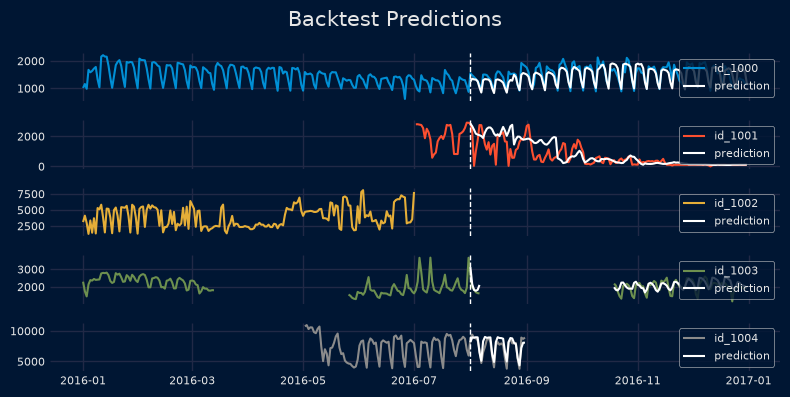

In [16]:
# Plot backtesting predictions
# ==============================================================================
fig, axs = plt.subplots(5, 1, figsize=(8, 4), sharex=True)

for i, s in enumerate(series_dict.keys()):
    axs[i].plot(series_dict[s], label=series_dict[s].name, color=colors[i])
    axs[i].axvline(
        pd.to_datetime(end_train), color='white', linestyle='--', linewidth=1
    )  # End train
    axs[i].plot(
        backtest_predictions.query("level == @s")['pred'], 
        label = 'prediction', 
        color = "white"
    )
    axs[i].legend(loc='upper right', fontsize=8)
    axs[i].tick_params(axis='both', labelsize=8)

fig.suptitle('Backtest Predictions', fontsize=15)
plt.tight_layout()

## How it works

For a foundation model, the differences among series matter because inference is done in **batches**: one call to the backend receives the context window and the covariates of every series and returns every forecast. Working series by series, a user would never notice the constraints that the backends impose on that batch:

- **Same covariate columns for every series in a batch.** Chronos-2, TS-ICL, TimesFM 3.0 and TabICL require that all the series in one call carry exactly the same covariate columns. A batch with different columns per series is either rejected by the backend or handed columns, filled with NaN, that some series do not have.
- **Padding the missing columns is not free.** Giving every series the union of all columns and filling the missing ones with NaN changes the forecast in some backends (Chronos-2 measurably), so it cannot be applied by default.
- **NaN in the data.** Backends differ in what they do with NaN in the target or in the covariates: some treat it as missing, some interpolate it, some drop the row, and one rejects it. No backend can use a context window that is entirely NaN.

All the rules about which series can share a backend call, how the exog must be aligned and when a series can be predicted live in one place: `FoundationModel.predict` and `backtesting_foundation`. The adapters only translate already-aligned inputs into a backend call, and each one declares its constraints through four read-only attributes:

| Attribute | Meaning |
|:----------|:--------|
| `allow_exog` | The backend uses exogenous variables at all. If `False`, `exog` and `context_exog` are ignored with an `IgnoredArgumentWarning`. |
| `supports_past_only_covariates` | Historical exog columns that have no future values are used as past-only covariates. If `False`, those columns are ignored with an `IgnoredArgumentWarning`. |
| `supports_heterogeneous_covariates` | The backend accepts, in one call, series whose exog columns differ. If `False`, `FoundationModel` groups the series by their exog columns and calls the adapter once per group. |
| `supports_nan_in_series` | The backend accepts NaN in the context. If `False`, a context with NaN raises a `ValueError` before the adapter is called. |

The attributes are exposed on `FoundationModel` and `ForecasterFoundation`, so they can be inspected before deciding how to prepare the data:

In [17]:
# Capabilities declared by the adapter (Chronos-2)
# ==============================================================================
print(f"allow_exog                        : {forecaster.allow_exog}")
print(f"supports_past_only_covariates     : {forecaster.supports_past_only_covariates}")
print(f"supports_heterogeneous_covariates : {forecaster.supports_heterogeneous_covariates}")
print(f"supports_nan_in_series            : {forecaster.supports_nan_in_series}")

allow_exog                        : True
supports_past_only_covariates     : True
supports_heterogeneous_covariates : False
supports_nan_in_series            : True


### Alignment and grouping before calling the backend

Whatever the input format (a dict of series, a wide DataFrame or a long-format DataFrame) and whichever method is called (`predict`, `predict_interval`, `predict_quantiles` or backtesting), the same steps run before the backend sees the data:

1. **The historical exog is cut to the context window of its series.** Rows outside the window are dropped. Context timestamps missing from the exog are added as NaN and reported once with a `MissingValuesWarning`.

2. **The future exog is aligned to the horizon of its series.** The horizon of each series starts right after its own last observation, so series that end on different dates get different horizons. The future exog is reindexed to exactly `steps` rows; missing timestamps are filled with NaN and reported with a `MissingValuesWarning`.

3. **The exog columns are validated series by series.** The columns of the future `exog` are compared with the historical exog of the same series (the one passed to `fit`, or `context_exog` when `context` is given). Column names are compared as sets, so the order does not matter.

    | Situation for one series | Result |
    |:-------------------------|:-------|
    | A future column has no historical values | `ValueError`. No backend can use a covariate without its history. |
    | A historical column has no future values | Past-only covariate. Used as such if `supports_past_only_covariates` is `True`, otherwise ignored with an `IgnoredArgumentWarning`. |
    | Same columns in both | Known-future covariate. |
    | No exog at all for this series | The series is forecast without covariates, even if other series have them. |

4. **Series are grouped by their exog columns when the backend needs it.** If `supports_heterogeneous_covariates` is `False`, the series are grouped by their pair `(past-only columns, future columns)` and the backend is called once per group, which is the minimum number of calls the backend allows. In the example above, Chronos-2 receives `id_1000` alone (two columns), `id_1003` alone (three columns) and `id_1001`, `id_1002` and `id_1004` together (four columns). The merged output keeps the order of the input series, and a dataset where every series has the same exog columns still makes a single call. For Chronos-2, `cross_learning=True` shares information among the series of the same group only, since the backend cannot see series from other groups.

5. **NaN in the context is checked.** If `supports_nan_in_series` is `False`, a context with NaN raises a `ValueError` naming the series before the backend is called.

This layer only **splits and aligns**. It never imputes, drops or fabricates values or columns: a series only ever carries its own exog columns, and a NaN that reaches the backend is either a NaN present in the user's data or a timestamp the user did not provide. Anything that changes values is a documented, backend-specific decision inside the adapter (see the reference below).

## Reference: requirements and limitations per backend

### Requirements common to every backend

The heterogeneity that skforecast absorbs is in lengths, time spans, exog columns and missing values. A few requirements still apply to every series in the batch, as they do for the rest of the library:

- All series must have the same **index type** (`DatetimeIndex` or `RangeIndex`) and the same **frequency**. Set it with `asfreq()` before fitting.
- A series cannot be **entirely NaN**.
- The exog of a series must share the index type of the series. Rows are matched by timestamp, so an exog can start or end on different dates than its series.
- Only the last `context_length` observations of each series are used. A series shorter than `context_length` is used in full; a series longer is truncated from the left.
- Covariates must be numeric (or boolean) for most backends. Chronos-2 and TS-ICL accept string and categorical columns natively; for the other backends, encode categoricals as numbers with `transformer_exog` or beforehand.

### Adapter capabilities

The table summarizes, for each adapter, the declared capabilities and how the backend treats missing values. "Grouped" means `supports_heterogeneous_covariates=False`: `FoundationModel` calls the backend once per group of series sharing the same exog columns.

| Adapter (`model_id` prefix) | Exog | Past-only covariates | Batch with different exog columns | NaN in target | NaN in covariates |
|:----------------------------|:-----|:---------------------|:----------------------------------|:--------------|:------------------|
| **Chronos-2** (`autogluon/chronos`) | Past and future | Yes | Grouped | Treated as missing values | Treated as missing values |
| **TimesFM 2.5** (`google/timesfm-2.5`) | Ignored | No | Single call (no covariates) | Linearly interpolated, leading NaN trimmed | Not applicable |
| **TimesFM 3.0** (`google/timesfm-3.0`) | Past and known-future, numeric only | Yes | Grouped | Linearly interpolated, leading NaN trimmed | Linearly interpolated |
| **Moirai-2** (`Salesforce/moirai`) | Ignored | No | Single call (no covariates) | Accepted | Not applicable |
| **TabICL** (`soda-inria/tabicl`) | Known-future | No (ignored with a warning) | Grouped | Rows with NaN target dropped by the library | Accepted with a warning from the library |
| **TabPFN-TS** (`priorlabs/tabpfn`) | Known-future | No (ignored with a warning) | Single call | Rows with NaN target dropped by the library | Missing cells imputed by the library |
| **TFC-T0** (`theforecastingcompany/t0`) | Known-future | No (ignored with a warning) | Single call | Accepted | NaN means "covariate absent" |
| **Synthefy Nori** (`Synthefy/Nori`) | Known-future, numeric only | No (ignored with a warning) | Single call (one in-context fit per series) | Rows with NaN target or NaN feature dropped by the adapter | Rows dropped from the context |
| **TS-ICL** (`taharnbl/TS-ICL`) | Past and future | Yes | Grouped | Accepted | Accepted |

Notes per adapter, limited to what the table cannot show:

- **Chronos-2.** The backend rejects a batch whose elements do not share the same covariate keys, so grouping is mandatory. Grouping also protects the forecasts: in tests with `chronos-2-small`, padding a series with two all-NaN covariate columns moved its forecast by about 3 to 30 percent of its scale, whereas forecasting it alone or with series that share its columns left it unchanged. Numeric and boolean columns are cast to `float32`; string and categorical columns are forwarded as-is.

- **TimesFM 3.0.** The backend stacks the covariate arrays of the batch, so grouping is mandatory. Series of different lengths in the same group are left-padded by the backend, and with covariates present the padding enters the model: in tests with `timesfm-3.0`, the forecast of a 30-observation series moved by about 2 percent of its scale when batched with a 91-observation series. Without covariates the effect is negligible. Leading NaN in the target trims the context and its covariates. Covariates must be numeric.

- **TimesFM 2.5 and Moirai-2.** They do not use covariates: any exog is ignored with an `IgnoredArgumentWarning` and all the series go in a single call. Mixed lengths and NaN are handled by the backend.

- **TabICL.** The backend builds one long-format frame per call and uses only the covariate columns present in both the context and the future data, so grouping keeps a series from receiving NaN-filled columns it does not have.

- **TabPFN-TS.** A single call serves every series: the library imputes the cells of the columns a series does not have and drops the rows with NaN target.

- **TFC-T0.** A single call serves every series: the adapter pools the columns of all series and fills the missing cells with NaN, which T0 defines as "covariate absent".

- **Synthefy Nori.** Each series is fitted in-context and predicted in its own `NoriRegressor` call, so there is no batching constraint. The regressor rejects NaN, so the adapter drops the context rows whose target or covariates are NaN while keeping the remaining rows correctly positioned in time. A series with no NaN-free row in its context raises a `ValueError`, and a future exog with gaps (filled with NaN by `FoundationModel`) may be rejected by the regressor.

- **TS-ICL.** As with Chronos-2, every element of a batch must carry identical covariate keys, so grouping is mandatory. Past-only covariates are supported.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#ff9100;"></i>
    <b style="color: #ff9100;">&#9888;&#65039; Warning</b>
</p>

The adapters are internal classes. Calling <code>adapter.predict</code> directly bypasses the alignment and grouping described here, and the backend error messages (for example Chronos-2's <code>Heterogeneous lists are not supported</code>) reappear. Always go through <code>ForecasterFoundation</code> or <code>FoundationModel</code>.

</div>